# Trip Advisor Hotel Reviews

### About this dataset
- Hotels play a crucial role in traveling and with the increased access to information new pathways of selecting the best ones emerged.
- With this dataset, consisting of 20k reviews crawled from Tripadvisor, you can explore what makes a great hotel and maybe even use this model in your travels!


# Objective

- 1-  Analyze and explore data
- 2- Cleaning the texts
- 3- Building a Machine Learning Model: classification
- 4- Build DNN Algorithm for Sentimentant analysis



# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read Dataset

In [2]:
hotel = pd.read_csv('hotel_reviews.csv')

# 1. Explore Dataset

#### 1. Display first 10 rows

In [3]:
hotel.head(10)

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
5,love monaco staff husband stayed hotel crazy w...,5
6,"cozy stay rainy city, husband spent 7 nights m...",5
7,"excellent staff, housekeeping quality hotel ch...",4
8,"hotel stayed hotel monaco cruise, rooms genero...",5
9,excellent stayed hotel monaco past w/e delight...,5


#### 2. Display bottom 3 rows of data

In [5]:
hotel.tail(3)

,Review,Rating
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1
20490,"people talking, ca n't believe excellent ratin...",2


#### 3. Define columns name and their attributes 

In [6]:
col_attributes = hotel.dtypes.reset_index()
col_attributes.columns = ['Column Name', 'Data Types']
print(col_attributes)

  Column Name Data Types
0      Review     object
1      Rating      int64


#### 4. Display total records and attributes

In [7]:
hotel.shape

(20491, 2)

#### 5. Display summary of a Dataframe or information about the dataset

In [8]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


# 2. Precleaning 

#### Identify missing values and count them for each column

In [9]:
hotel.isnull().sum()

Review    0
Rating    0
dtype: int64

The dataset was provided with non missing values. So that, there is no process for cleanning or dropping the dataset.

###### Identify duplicate records

In [10]:
duplicates = hotel.duplicated()

In [11]:
# Check if there are any remaining duplicate records
hotel.duplicated().sum()

0

In [12]:
duplicates = hotel.duplicated(subset='Review', keep=False)

# Now, print the duplicate reviews
print(hotel[duplicates])

Empty DataFrame
Columns: [Review, Rating]
Index: []


There is no duplicates value are shown in this dataset.

###### Save Dataset

In [13]:
hotel.to_csv('cleaned_hotel.csv', index=False)

# 3. EDA

#### Import new dataset which is after pre-processing process 

In [14]:
reviews = pd.read_csv('cleaned_hotel.csv')

In [15]:
reviews.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


##### Data Visualization

1. What is the distribution of ratings in the dataset?
- This question explores how the ratings are distributed, which can help in understanding customer satisfaction or identifying bias towards particular ratings.

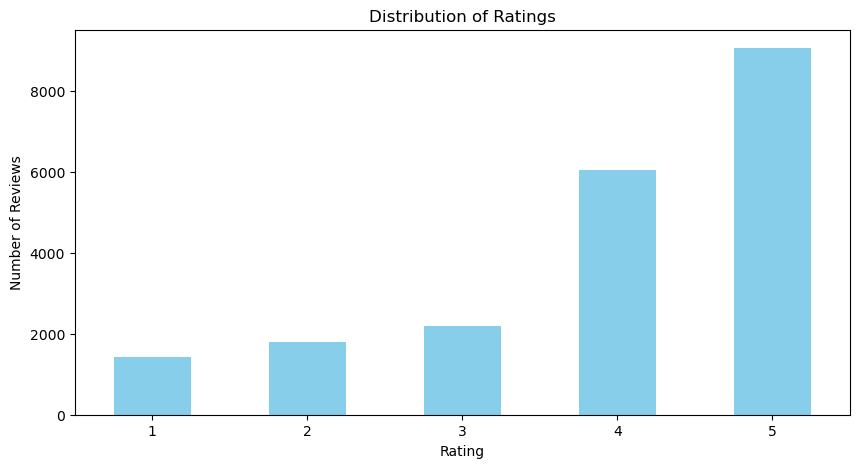

In [16]:
# Plotting the distribution of ratings
hotel['Rating'].value_counts().sort_index().plot(kind='bar', color='skyblue', figsize=(10, 5))
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

2. What are the top 5 most frequent words used in the reviews?
- Analyzing the most frequent words can give insights into common themes or issues mentioned by customers.

In [17]:
from collections import Counter
import re

# Function to clean text data
def clean_text(text):
    text = re.sub(r'\W', ' ', str(text))
    text = text.lower()
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\^[a-zA-Z]\s+', ' ', text) 
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    return text

# Apply the cleaning function
reviews['cleaned_review'] = reviews['Review'].apply(clean_text)

# Extracting words and count them
all_words = ' '.join(reviews['cleaned_review']).split()
word_counts = Counter(all_words)
print("Top 5 most frequent words used in the reviews:")
print(word_counts.most_common(5))


Top 5 most frequent words used in the reviews:
[('hotel', 49814), ('room', 35331), ('not', 31709), ('great', 21475), ('t', 18737)]


3. What is the average rating of the reviews that mention the word "clean"?
- This question examines whether reviews mentioning "clean" have a higher or lower average rating, which can be indicative of cleanliness being a significant factor in overall satisfaction.

In [18]:
# Function to check if 'clean' is in the review
reviews['mentions_clean'] = reviews['Review'].apply(lambda x: 'clean' in x.lower())

# Calculate the average rating where 'clean' is mentioned
average_rating_clean = reviews[reviews['mentions_clean']]['Rating'].mean()
print(f"The average rating for reviews that mention 'clean' is {average_rating_clean:.2f}")


The average rating for reviews that mention 'clean' is 4.02


The highest work repeat in the review rating 5

In [19]:
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS
import re

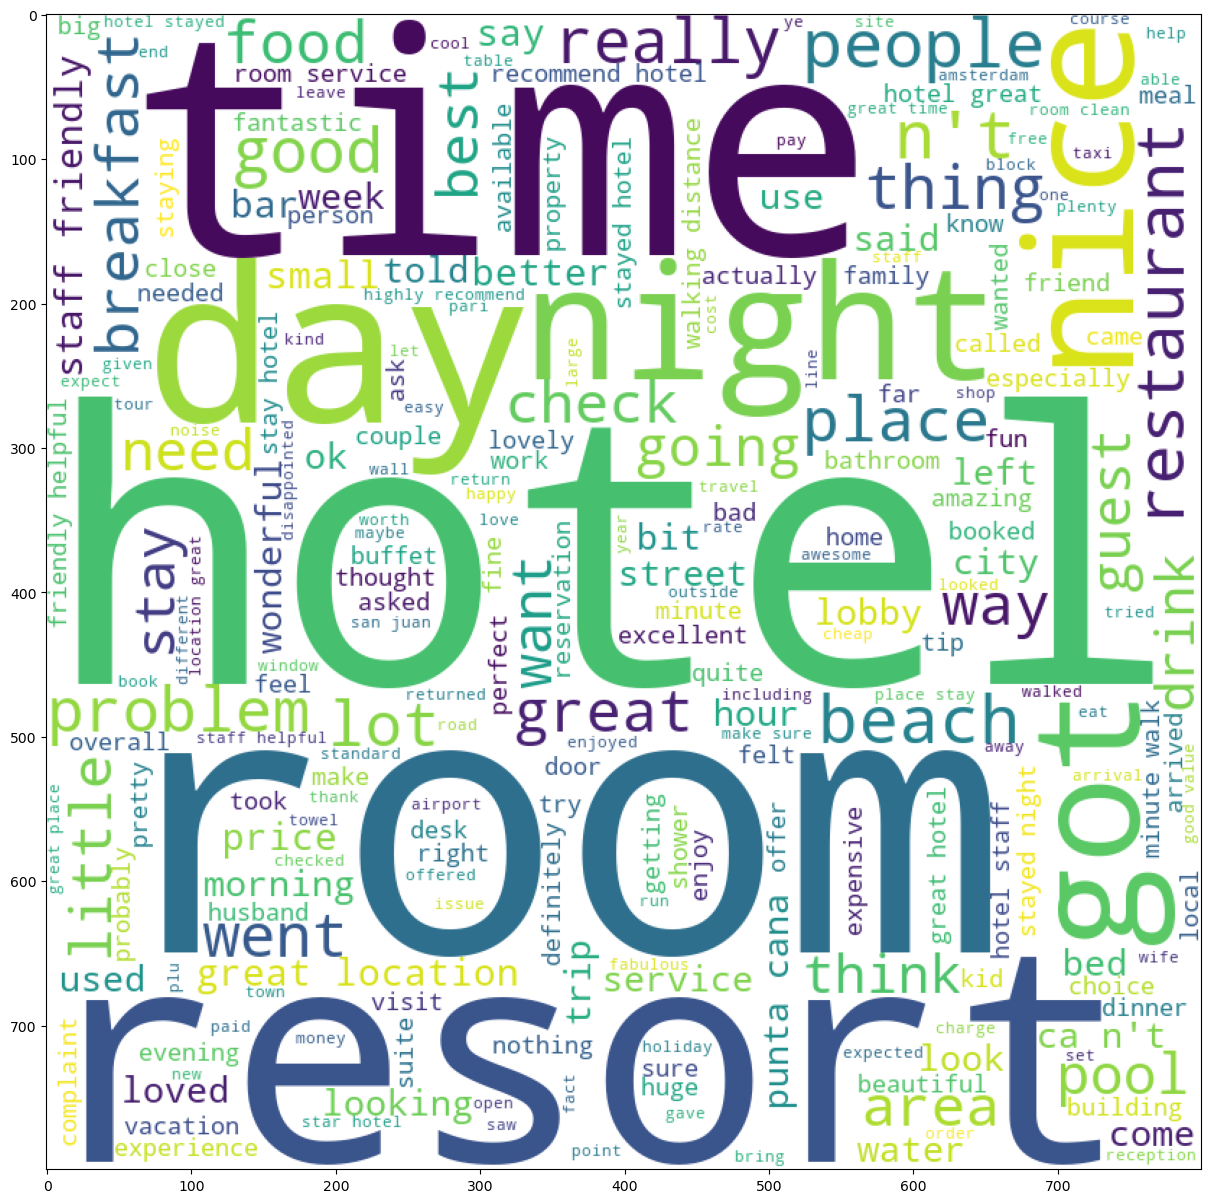

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
wc1 = WordCloud(max_words=1000, min_font_size=10, height=800,width=800,background_color="white").generate(' '.join(reviews['Review']))

plt.imshow(wc1)

## Rating Analysis 

#### Total Satisfied Rating 

In [21]:
# Calculate the percentage of each rating
rating_percentages = hotel['Rating'].value_counts(normalize=True) * 100

# Format the output for better readability
rating_percentages = rating_percentages.sort_index().map('{:.2f}%'.format)

# Print the percentages
print("Percentage of each rating:")
print(rating_percentages)


Percentage of each rating:
Rating
1     6.93%
2     8.75%
3    10.66%
4    29.47%
5    44.19%
Name: proportion, dtype: object


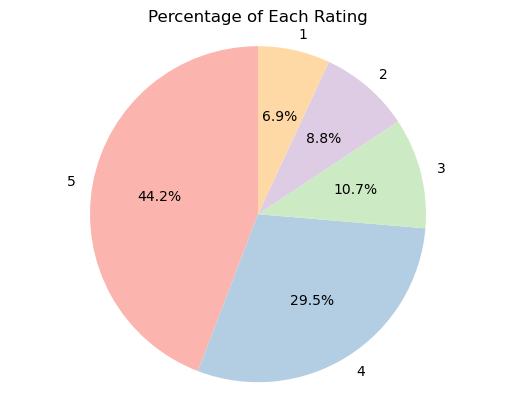

In [22]:
# Calculate the percentage of each rating
rating_percentages = reviews['Rating'].value_counts(normalize=True) * 100

# Plotting the pie chart
fig, ax = plt.subplots()
ax.pie(rating_percentages, labels=rating_percentages.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of Each Rating')
plt.show()

In [23]:
hotel_rank=reviews[reviews["Rating"]==4]
print(hotel_rank)

                                                  Review  Rating  \
0      nice hotel expensive parking got good deal sta...       4   
7      excellent staff, housekeeping quality hotel ch...       4   
11     nice value seattle stayed 4 nights late 2007. ...       4   
12     nice hotel good location hotel kimpton design ...       4   
14     great hotel night quick business trip, loved l...       4   
...                                                  ...     ...   
20475  good stay spent night pacific northwest/northe...       4   
20477  nice hotel pioneer square area stayed late aug...       4   
20478  just fine, hotel located pioneer square just q...       4   
20483  good bed clean convenient just night happy sta...       4   
20487  great location price view hotel great quick pl...       4   

                                          cleaned_review  mentions_clean  
0      nice hotel expensive parking got good deal sta...            True  
7      excellent staff housekeepi

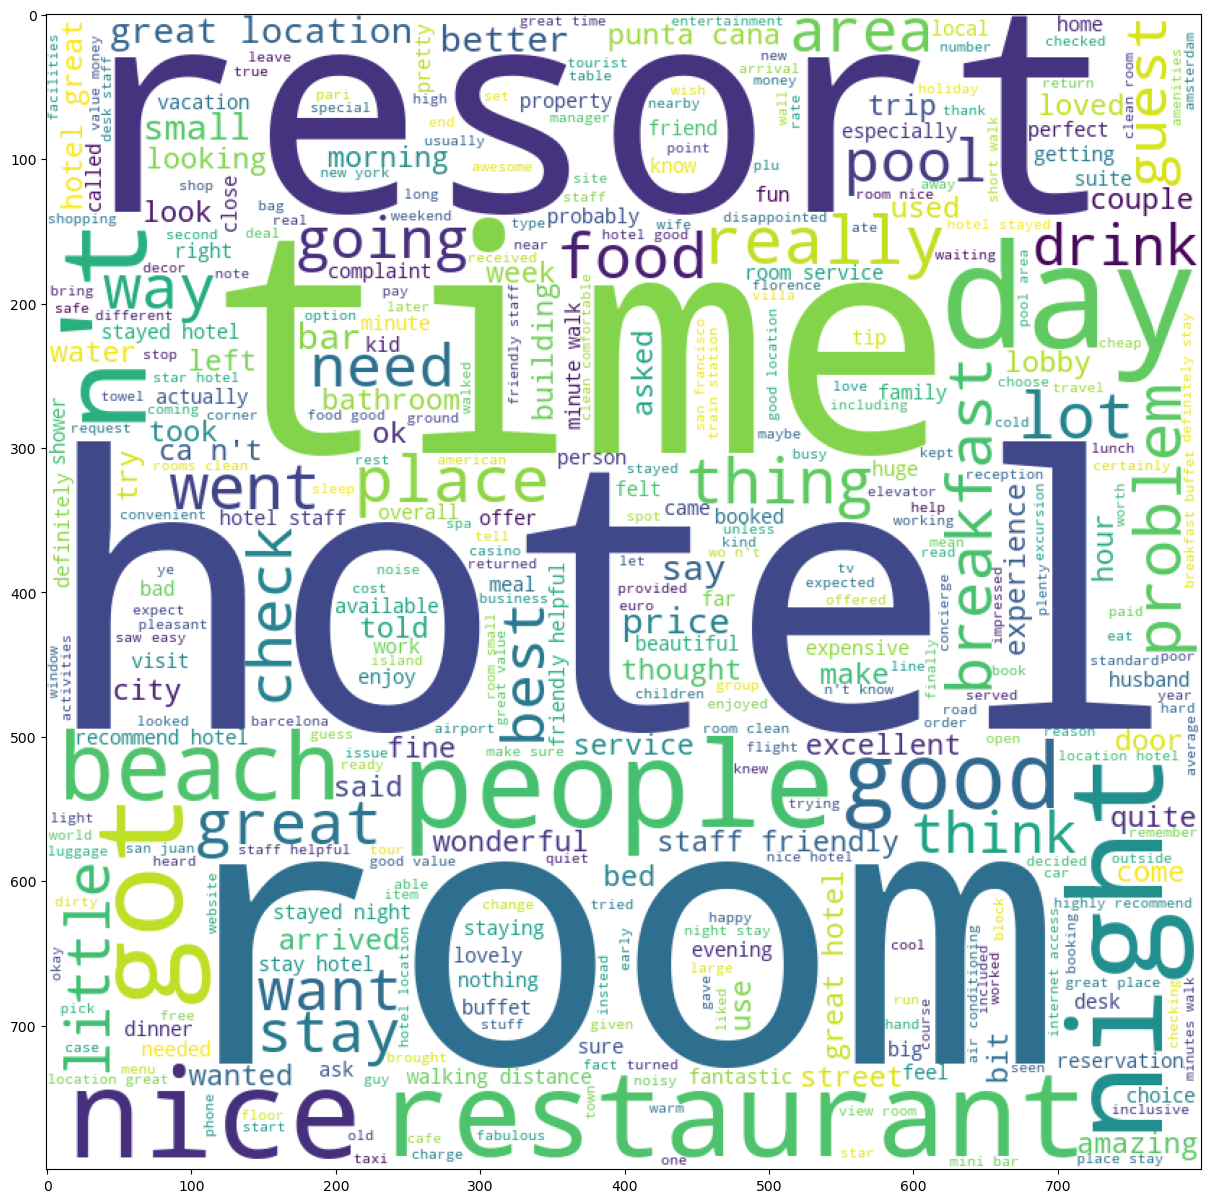

In [25]:
# the highest work repeat in the review rating 4

plt.figure(figsize=(15,15))
wc2 = WordCloud(max_words=1000, min_font_size=10, height=800,width=800,background_color="white").generate(' '.join(reviews['Review']))

plt.imshow(wc2)

# 4. Development

In [26]:
#Importing the basic librarires for building model - classification and clustering

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import  MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.feature_extraction.text import CountVectorizer 

from sklearn.preprocessing import LabelEncoder,StandardScaler

In [27]:
# import library for Natural Language Toolkit

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer